## Financial Inclusion in Malawi - Barriers Analysis

**Global Findex 2024 Microdata Analysis**  
**Author:** Brian Thuwala  
**Notebook:** 03_barriers_analysis.ipynb  

---

## Executive Summary

This analysis provides a comprehensive examination of the structural, economic, institutional, and behavioral barriers to financial inclusion in Malawi using the 2024 Global Findex microdata. Despite widespread mobile phone ownership (56.2% among the unbanked), significant portions of the population remain excluded from formal financial services due to multidimensional constraints. Key findings reveal that:

- **87.6%** of Malawian adults lack formal financial accounts
- **49.6%** are completely unbanked (no account of any type)
- **38.0%** rely exclusively on mobile money services
- **80.1%** cite "lack of money" as the primary barrier to mobile money adoption
- Women in rural areas experience the highest exclusion rates (>90%)

The analysis employs robust statistical methods, weighted calculations, and visual analytics to identify actionable insights for policymakers and financial service providers.

---

## Introduction & Research Context

### Analytical Positioning

This notebook represents the third component of a comprehensive financial inclusion analysis series:

1. **Notebook 01:** Established data integrity, variable validation, and survey weight application for nationally representative analysis
2. **Notebook 02:** Documented descriptive patterns of financial access and exclusion across demographic and socioeconomic groups
3. **Notebook 03:** (Current) Shifts from descriptive measurement to explanatory analysis of structural barriers

### Research Question

**Primary Research Question:**  
*Why do significant segments of Malawi's population remain financially excluded despite widespread mobile phone ownership and expanding digital financial services infrastructure?*

### Analytical Strategy

Due to high missingness in standard bank account barrier questions within Malawi's 2024 Global Findex survey, this analysis adopts an alternative methodological approach using:

- **Digital connectivity indicators** (mobile phone ownership, internet access)
- **Mobile money-specific barrier variables**
- **Identification ownership** (foundational ID possession)
- **Payment usage patterns** and financial behavior indicators

---

### 2.1 Data Dictionary (Key Variables)

| Variable | Description | Values/Coding |
|----------|-------------|---------------|
| `account_fin` | Formal financial account ownership | 1 = Yes, 0 = No |
| `account` | Any financial account (formal or informal) | 1 = Yes, 0 = No |
| `con1` | Mobile phone ownership | 1 = Yes, 2 = No |
| `fin46` | Foundational ID ownership | 1 = Yes, 2 = No |
| `female` | Gender indicator | 1 = Female, 2 = Male |
| `urbanicity` | Location classification | 1 = Rural, 2 = Urban |
| `wgt` | Survey weight | Continuous (population representativeness) |
| `fin14a` | Mobile money barrier: Agents too far | 1 = Yes, 2 = No |
| `fin14b` | Mobile money barrier: Too expensive | 1 = Yes, 2 = No |
| `fin14c` | Mobile money barrier: Lack documentation | 1 = Yes, 2 = No |
| `fin14d` | Mobile money barrier: Lack of money | 1 = Yes, 2 = No |
| `fin14e` | Mobile money barrier: Security worries | 1 = Yes, 2 = No |

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP: Professional Theme, Libraries & Helpers
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ─── COLOR PALETTE ────────────────────────────────────────────────────────
COLORS = {
    'primary': '#1B4F72', 'secondary': '#2E86C1', 'accent': '#E67E22',
    'success': '#27AE60', 'danger': '#C0392B', 'warning': '#F39C12',
    'light': '#F8F9FA', 'dark': '#2C3E50', 'muted': '#5D6D7E',
    'bg': '#FAFBFC', 'grid': '#E8ECF0', 'text': '#2C3E50',
}
PALETTE_CAT = ['#1B4F72', '#2E86C1', '#27AE60', '#E67E22', '#C0392B', '#8E44AD', '#F39C12']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'], 'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'], 'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'], 'grid.alpha': 0.6, 'grid.linewidth': 0.5,
    'figure.figsize': (14, 7), 'font.size': 11, 'axes.titlesize': 16,
    'axes.labelsize': 12, 'figure.titlesize': 18, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'figure.dpi': 120,
})

def weighted_mean(series, weights):
    valid_mask = ~series.isna() & ~weights.isna()
    if valid_mask.sum() == 0: return np.nan
    return np.average(series[valid_mask], weights=weights[valid_mask])

def weighted_crosstab(df, var1, var2, weight_var):
    valid = df[var1].notna() & df[var2].notna() & df[weight_var].notna()
    return pd.crosstab(df.loc[valid, var1], df.loc[valid, var2],
                       values=df.loc[valid, weight_var], aggfunc="sum", normalize=False).fillna(0)

def add_source_note(fig, extra=""):
    txt = "Source: World Bank Global Findex 2024 — Malawi Microdata (n = 1,000; survey-weighted estimates)"
    if extra: txt += f"\n{extra}"
    fig.text(0.02, -0.02, txt, fontsize=10, color=COLORS['muted'], fontstyle='italic', ha='left', va='top')

def styled_table(data, title="", bar_col=None, precision=1):
    styler = data.style.set_caption(title).set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),
            ('color', COLORS['primary']),('text-align','left'),('padding-bottom','8px')]},
        {'selector': 'thead th', 'props': [('background-color', COLORS['primary']),('color','white'),
            ('font-weight','bold'),('text-align','center'),('padding','8px 12px'),
            ('border-bottom', f'2px solid {COLORS["accent"]}')]},
        {'selector': 'tbody td', 'props': [('text-align','center'),('padding','6px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody th', 'props': [('text-align','left'),('padding','6px 12px'),
            ('font-weight','500'),('background-color', COLORS['light']),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': '', 'props': [('border-collapse','collapse'),('width','100%')]},
    ]).format(precision=precision)
    if bar_col and bar_col in data.columns:
        styler = styler.bar(subset=[bar_col], color=COLORS['secondary'], vmin=0)
    return styler

def kpi_cards(metrics):
    cards = ""
    for label, value, icon, color in metrics:
        cards += f"""<div style="flex:1;min-width:140px;background:white;border-radius:12px;
            padding:18px 16px;text-align:center;box-shadow:0 2px 12px rgba(0,0,0,0.06);
            border-top:4px solid {color};margin:6px;">
            <div style="font-size:28px;margin-bottom:4px;">{icon}</div>
            <div style="font-size:28px;font-weight:800;color:{color};letter-spacing:-0.5px;">{value}</div>
            <div style="font-size:12px;color:#4a5568;margin-top:4px;line-height:1.3;">{label}</div>
        </div>"""
    display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:8px;justify-content:center;
        padding:10px 0;max-width:900px;margin:auto;">{cards}</div>"""))

print("✅ Professional theme loaded")

✅ Professional theme loaded


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA LOADING & OVERVIEW
# ═══════════════════════════════════════════════════════════════════════════════

DATA_PATH = "../data/raw/Findex_Microdata_2025_updateMalawi.csv"
df = pd.read_csv(DATA_PATH)

# ─── KPI Cards ────────────────────────────────────────────────────────────
kpi_cards([
    ("Respondents", f"{df.shape[0]:,}", "👥", COLORS['primary']),
    ("Variables", f"{df.shape[1]}", "📊", COLORS['secondary']),
    ("Memory", f"{df.memory_usage().sum()/1024**2:.1f} MB", "💾", COLORS['accent']),
    ("Barrier Vars (fin14*)", f"{len([c for c in df.columns if c.startswith('fin14')])}", "🚧", COLORS['danger']),
])

# ─── Key Variables Table ──────────────────────────────────────────────────
key_vars = {
    'account_fin': 'Formal financial account', 'account': 'Any financial account',
    'account_mob': 'Mobile money account', 'con1': 'Mobile phone ownership',
    'fin46': 'Foundational ID ownership', 'fin14a': 'Barrier: Agents too far',
    'fin14b': 'Barrier: Too expensive', 'fin14c': 'Barrier: Lack documentation',
    'fin14d': 'Barrier: Lack of money', 'fin14e': 'Barrier: Security worries',
    'female': 'Gender (1=F, 2=M)', 'urbanicity': 'Residence (1=Rural, 2=Urban)',
    'wgt': 'Survey weight',
}
rows = []
for var, desc in key_vars.items():
    nn = df[var].notna().sum() if var in df.columns else 0
    rows.append({'Variable': var, 'Description': desc,
                 'Valid N': nn, 'Coverage (%)': nn / len(df) * 100})
display(styled_table(pd.DataFrame(rows).set_index('Variable'),
                     '📋 Key Variables for Barriers Analysis', bar_col='Coverage (%)'))

,Description,Valid N,Coverage (%)
Variable,,,
account_fin,Formal financial account,1000,100.0
account,Any financial account,1000,100.0
account_mob,Mobile money account,1000,100.0
con1,Mobile phone ownership,1000,100.0
fin46,Foundational ID ownership,964,96.4
fin14a,Barrier: Agents too far,409,40.9
fin14b,Barrier: Too expensive,409,40.9
fin14c,Barrier: Lack documentation,409,40.9
fin14d,Barrier: Lack of money,409,40.9


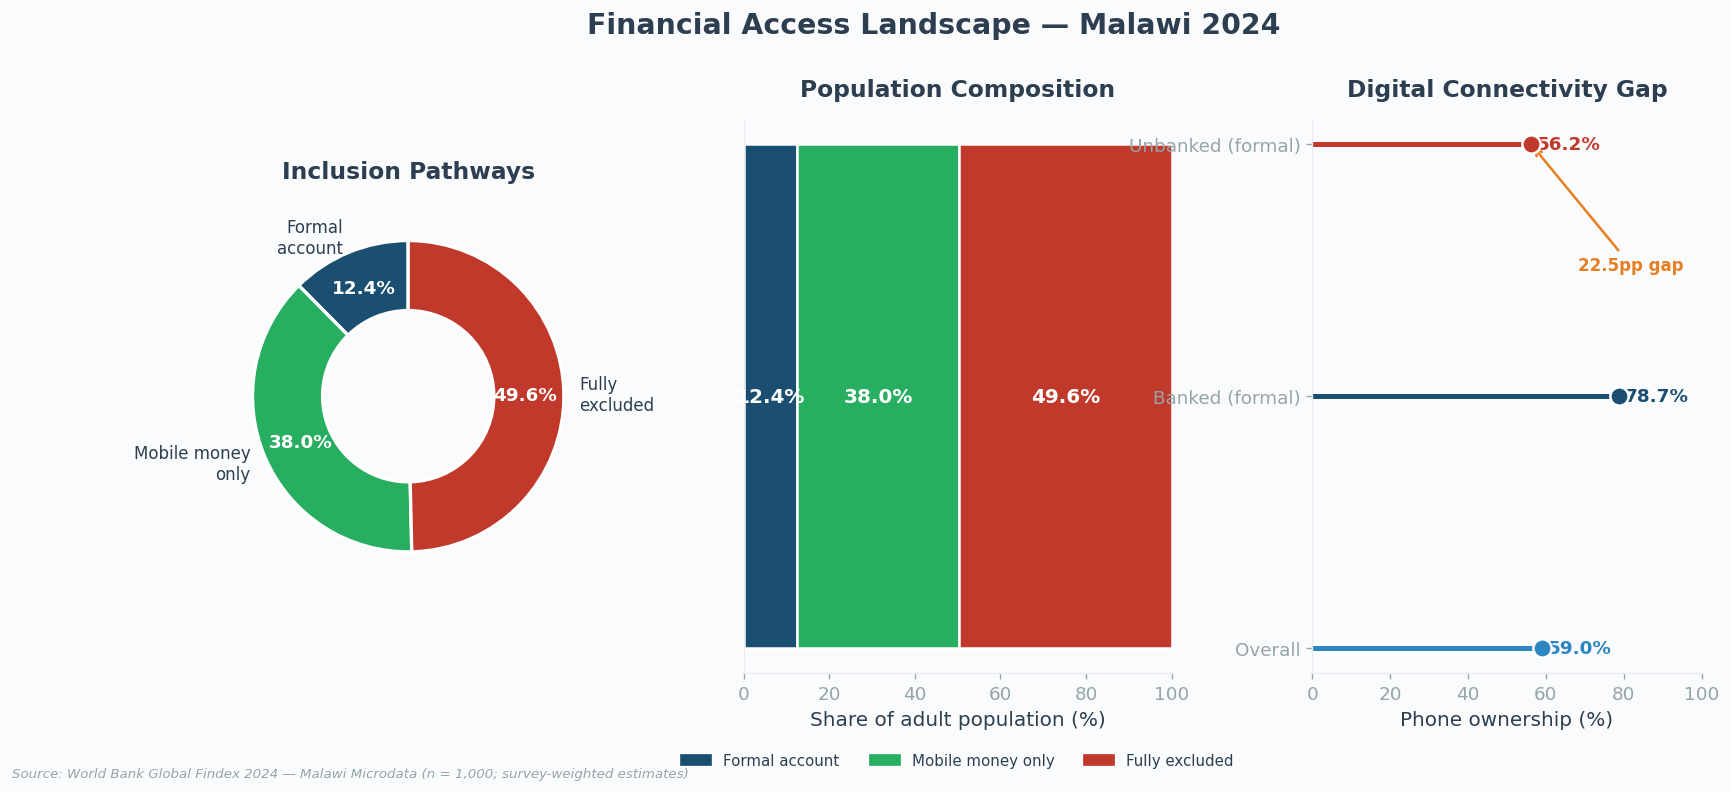

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINANCIAL ACCESS BASELINE & DIGITAL CONNECTIVITY
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Compute exclusion metrics ────────────────────────────────────────────
unbanked_formal = df["account_fin"] == 0
unbanked_any    = df["account"] == 0
mobile_only     = (df["account_fin"] == 0) & (df["account"] == 1)
fully_excluded  = df["account"] == 0

pct_formal      = weighted_mean(~unbanked_formal, df["wgt"]) * 100
pct_any         = weighted_mean(~unbanked_any, df["wgt"]) * 100
pct_mobile_only = weighted_mean(mobile_only, df["wgt"]) * 100
pct_excluded    = weighted_mean(fully_excluded, df["wgt"]) * 100

# ─── KPI Cards ────────────────────────────────────────────────────────────
kpi_cards([
    ("Formal Account", f"{pct_formal:.1f}%", "🏦", COLORS['primary']),
    ("Any Account", f"{pct_any:.1f}%", "💳", COLORS['secondary']),
    ("Mobile Only", f"{pct_mobile_only:.1f}%", "📱", COLORS['success']),
    ("Fully Excluded", f"{pct_excluded:.1f}%", "🚫", COLORS['danger']),
])

# ─── Phone ownership by financial status ──────────────────────────────────
phone_metrics = {}
for lbl, mask in [('Unbanked (formal)', unbanked_formal),
                  ('Banked (formal)', ~unbanked_formal),
                  ('Overall', pd.Series(True, index=df.index))]:
    v = mask & df["con1"].isin([1, 2])
    phone_metrics[lbl] = weighted_mean(df.loc[v, "con1"].eq(1), df.loc[v, "wgt"]) * 100

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Financial Access Landscape  (3 panels)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 6))
gs  = GridSpec(1, 3, width_ratios=[1, 1.1, 1], wspace=0.35)

# ── Panel 1: Donut — Inclusion pathways ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
sizes  = [pct_formal, pct_mobile_only, pct_excluded]
labels = ['Formal\naccount', 'Mobile money\nonly', 'Fully\nexcluded']
cols   = [COLORS['primary'], COLORS['success'], COLORS['danger']]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=cols, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title('Inclusion Pathways', fontsize=14, fontweight='bold', pad=14)

# ── Panel 2: Horizontal waterfall — account ownership ────────────────────
ax2 = fig.add_subplot(gs[1])
cats   = ['Formal account', 'Mobile money only', 'Fully excluded']
vals   = [pct_formal, pct_mobile_only, pct_excluded]
cum_left = [0, pct_formal, pct_formal + pct_mobile_only]
bar_cols = [COLORS['primary'], COLORS['success'], COLORS['danger']]
for i, (cl, v, c) in enumerate(zip(cum_left, vals, bar_cols)):
    ax2.barh(0, v, left=cl, color=c, height=0.55, edgecolor='white', linewidth=1.5)
    ax2.text(cl + v / 2, 0, f'{v:.1f}%', ha='center', va='center',
             fontsize=12, fontweight='bold', color='white')
ax2.set_xlim(0, 100); ax2.set_yticks([]); ax2.set_xlabel('Share of adult population (%)')
ax2.set_title('Population Composition', fontsize=14, fontweight='bold', pad=14)
# legend
handles = [mpatches.Patch(color=c, label=l) for l, c in zip(cats, bar_cols)]
ax2.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12),
           ncol=3, fontsize=9, frameon=False)

# ── Panel 3: Lollipop — phone ownership by financial status ──────────────
ax3 = fig.add_subplot(gs[2])
groups = list(phone_metrics.keys())
vals3  = list(phone_metrics.values())
y_pos  = np.arange(len(groups))
bar_c  = [COLORS['danger'], COLORS['primary'], COLORS['secondary']]
for i, (g, v) in enumerate(zip(groups, vals3)):
    ax3.plot([0, v], [i, i], color=bar_c[i], linewidth=3, solid_capstyle='round')
    ax3.scatter(v, i, color=bar_c[i], s=120, zorder=5, edgecolors='white', linewidth=1.5)
    ax3.text(v + 1.5, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold', color=bar_c[i])
ax3.set_yticks(y_pos); ax3.set_yticklabels(groups, fontsize=11)
ax3.set_xlim(0, 100); ax3.set_xlabel('Phone ownership (%)')
ax3.set_title('Digital Connectivity Gap', fontsize=14, fontweight='bold', pad=14)
ax3.invert_yaxis()

# annotation – gap
gap = phone_metrics['Banked (formal)'] - phone_metrics['Unbanked (formal)']
ax3.annotate(f'{gap:.1f}pp gap', xy=(phone_metrics['Unbanked (formal)'], 0),
             xytext=(phone_metrics['Unbanked (formal)'] + 12, 0.5),
             fontsize=10, color=COLORS['accent'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

fig.suptitle('Financial Access Landscape — Malawi 2024', fontsize=17, fontweight='bold', y=1.03)
add_source_note(fig)
plt.savefig('../outputs/figures/access_landscape.png', bbox_inches='tight', dpi=200)
plt.show()

### Key Baseline Findings

1. **High Formal Exclusion:** 87.6% of Malawian adults lack formal financial accounts, indicating a significant gap in traditional banking penetration.

2. **Informal Sector Importance:** 38.0% rely exclusively on mobile money, highlighting the critical role of digital financial services as an alternative pathway.

3. **Complete Exclusion Remains Substantial:** Nearly half the population (49.6%) has no financial account of any type, representing a core challenge for financial inclusion initiatives.

### Connectivity Insights

**Key Finding:** While 56.2% of unbanked individuals own mobile phones, this digital infrastructure alone does not translate into financial inclusion. The 22.5 percentage point gap between banked (78.7%) and unbanked phone ownership suggests that:

1. **Infrastructure is a necessary but insufficient condition** for financial inclusion
2. **Other barriers** (economic, institutional, behavioral) prevent phone ownership from translating into financial account ownership
3. **Digital divide persists** even within the unbanked population

,Variable,Prevalence (%),Valid N
Barrier,,,
Lack of money,fin14d,80.1,409
Lack documentation,fin14c,34.6,409
Security worries,fin14e,28.5,408
Too expensive,fin14b,27.1,406
Agents too far,fin14a,14.7,409


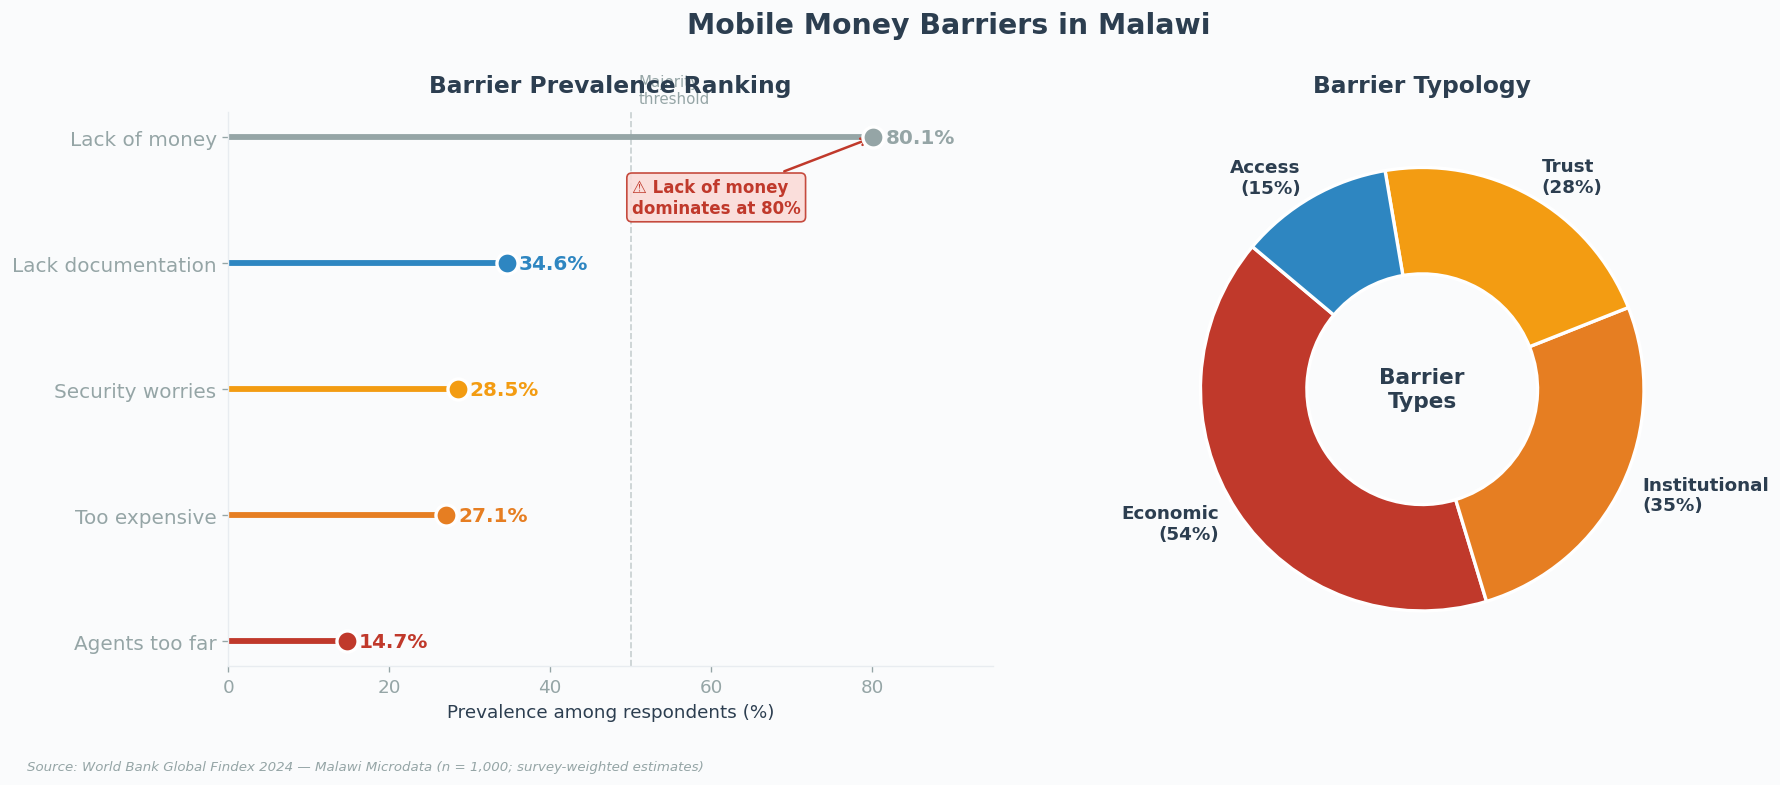

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# MOBILE MONEY–SPECIFIC BARRIERS
# ═══════════════════════════════════════════════════════════════════════════════

mm_barrier_vars = {
    "fin14a": "Agents too far",   "fin14b": "Too expensive",
    "fin14c": "Lack documentation","fin14d": "Lack of money",
    "fin14e": "Security worries",
}

mm_barriers = []
for var, label in mm_barrier_vars.items():
    valid = df[var].isin([1, 2])
    if valid.sum() > 0:
        pct = weighted_mean(df.loc[valid, var].eq(1), df.loc[valid, "wgt"]) * 100
        mm_barriers.append({"Barrier": label, "Variable": var,
                            "Prevalence (%)": pct, "Valid N": int(valid.sum())})

mm_df = pd.DataFrame(mm_barriers).sort_values("Prevalence (%)", ascending=False).reset_index(drop=True)
mm_df.index = mm_df.index + 1
mm_df.index.name = 'Rank'

# ─── Styled table ────────────────────────────────────────────────────────
display(styled_table(mm_df.set_index('Barrier'),
                     '🚧 Mobile Money Barrier Prevalence (Weighted)',
                     bar_col='Prevalence (%)'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Barrier Lollipop + Typology Donut  (2 panels)
# ═══════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={'width_ratios': [1.3, 1]})

# ── Panel 1: Horizontal lollipop ─────────────────────────────────────────
n = len(mm_df)
y_pos = np.arange(n)
palette_lollipop = [COLORS['danger'], COLORS['accent'], COLORS['warning'],
                    COLORS['secondary'], COLORS['muted']][:n]
sorted_df = mm_df.sort_values('Prevalence (%)', ascending=True)

for i, (_, row) in enumerate(sorted_df.iterrows()):
    ax1.plot([0, row['Prevalence (%)']], [i, i], color=palette_lollipop[i],
             linewidth=3.5, solid_capstyle='round')
    ax1.scatter(row['Prevalence (%)'], i, color=palette_lollipop[i],
                s=160, zorder=5, edgecolors='white', linewidth=2)
    ax1.text(row['Prevalence (%)'] + 1.5, i, f"{row['Prevalence (%)']:.1f}%",
             va='center', fontsize=12, fontweight='bold', color=palette_lollipop[i])

ax1.set_yticks(y_pos)
ax1.set_yticklabels(sorted_df['Barrier'], fontsize=12)
ax1.set_xlim(0, 95)
ax1.set_xlabel('Prevalence among respondents (%)', fontsize=11)
ax1.set_title('Barrier Prevalence Ranking', fontsize=14, fontweight='bold', pad=12)
ax1.axvline(50, ls='--', color=COLORS['muted'], alpha=0.5, lw=1)
ax1.text(51, n - 0.5, 'Majority\nthreshold', fontsize=9, color=COLORS['muted'], va='top')

# highlight dominant
top_val = sorted_df.iloc[-1]
ax1.annotate(f"⚠ {top_val['Barrier']}\ndominates at {top_val['Prevalence (%)']:.0f}%",
             xy=(top_val['Prevalence (%)'], n - 1),
             xytext=(top_val['Prevalence (%)'] - 30, n - 1.6),
             fontsize=10, color=COLORS['danger'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='#FADBD8', ec=COLORS['danger'], alpha=0.9))

# ── Panel 2: Typology donut ─────────────────────────────────────────────
barrier_types = {
    'Economic':      ['Lack of money', 'Too expensive'],
    'Institutional': ['Lack documentation'],
    'Trust':         ['Security worries'],
    'Access':        ['Agents too far'],
}
type_vals, type_labels, type_cols = [], [], []
type_color_map = {'Economic': COLORS['danger'], 'Institutional': COLORS['accent'],
                  'Trust': COLORS['warning'], 'Access': COLORS['secondary']}
for bt, barriers in barrier_types.items():
    avg = mm_df.loc[mm_df['Barrier'].isin(barriers), 'Prevalence (%)'].mean()
    type_vals.append(avg); type_labels.append(bt); type_cols.append(type_color_map[bt])

wedges, texts, autotexts = ax2.pie(
    type_vals, labels=[f'{l}\n({v:.0f}%)' for l, v in zip(type_labels, type_vals)],
    colors=type_cols, autopct='', startangle=140,
    wedgeprops=dict(width=0.48, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Barrier Typology', fontsize=14, fontweight='bold', pad=12)

# center text
ax2.text(0, 0, 'Barrier\nTypes', ha='center', va='center',
         fontsize=13, fontweight='bold', color=COLORS['text'])

fig.suptitle('Mobile Money Barriers in Malawi', fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig)
plt.savefig('../outputs/figures/mm_barriers.png', bbox_inches='tight', dpi=200)
plt.show()

,Avg Prevalence (%),Components,N Barriers
Barrier Type,,,
Economic,53.6,"Lack of money, Too expensive",2
Institutional,34.6,Lack documentation,1
Trust / Security,28.5,Security worries,1
Access / Infrastructure,14.7,Agents too far,1


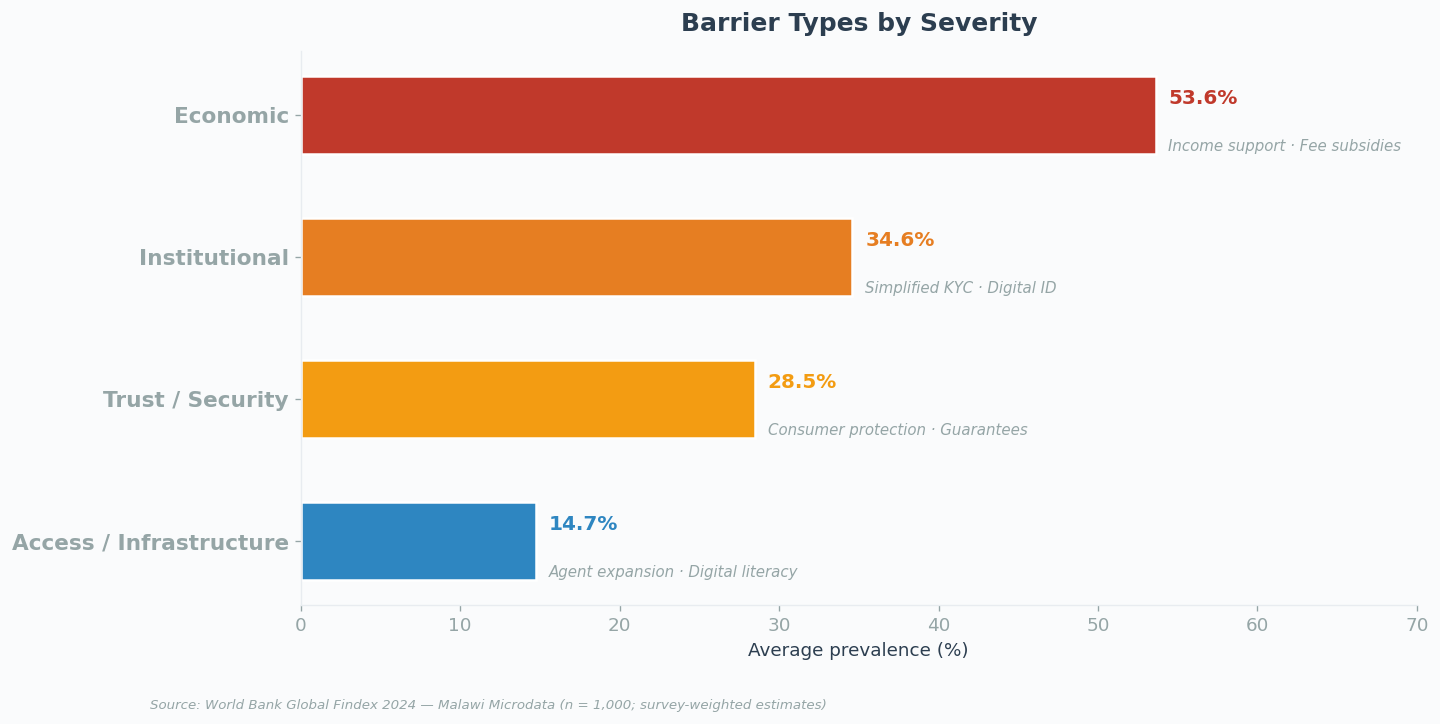

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# BARRIER TYPOLOGY — DEEP DIVE
# ═══════════════════════════════════════════════════════════════════════════════

barrier_types = {
    'Economic':             ['Lack of money', 'Too expensive'],
    'Institutional':        ['Lack documentation'],
    'Trust / Security':     ['Security worries'],
    'Access / Infrastructure': ['Agents too far'],
}
type_color_map = {'Economic': COLORS['danger'], 'Institutional': COLORS['accent'],
                  'Trust / Security': COLORS['warning'], 'Access / Infrastructure': COLORS['secondary']}

type_rows = []
for bt, barriers in barrier_types.items():
    sub = mm_df.loc[mm_df['Barrier'].isin(barriers)]
    type_rows.append({'Barrier Type': bt,
                      'Avg Prevalence (%)': sub['Prevalence (%)'].mean(),
                      'Components': ', '.join(barriers),
                      'N Barriers': len(barriers)})
type_df = pd.DataFrame(type_rows).sort_values('Avg Prevalence (%)', ascending=False)

display(styled_table(type_df.set_index('Barrier Type'),
                     '📊 Barrier Typology Summary', bar_col='Avg Prevalence (%)'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Typology bar + policy annotation
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(type_df))
cols = [type_color_map[t] for t in type_df['Barrier Type']]

bars = ax.barh(y_pos, type_df['Avg Prevalence (%)'], height=0.55,
               color=cols, edgecolor='white', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(type_df['Barrier Type'], fontsize=13, fontweight='bold')
ax.set_xlim(0, 70)
ax.set_xlabel('Average prevalence (%)', fontsize=11)
ax.set_title('Barrier Types by Severity', fontsize=15, fontweight='bold', pad=12)
ax.invert_yaxis()

# value labels + policy tags
policy_tags = {
    'Economic': 'Income support · Fee subsidies',
    'Institutional': 'Simplified KYC · Digital ID',
    'Trust / Security': 'Consumer protection · Guarantees',
    'Access / Infrastructure': 'Agent expansion · Digital literacy',
}
for i, (_, row) in enumerate(type_df.iterrows()):
    v = row['Avg Prevalence (%)']
    ax.text(v + 0.8, i - 0.12, f'{v:.1f}%', va='center', fontsize=12, fontweight='bold', color=cols[i])
    ax.text(v + 0.8, i + 0.22, policy_tags.get(row['Barrier Type'], ''),
            va='center', fontsize=9, color=COLORS['muted'], fontstyle='italic')

add_source_note(fig)
plt.savefig('../outputs/figures/barrier_typology.png', bbox_inches='tight', dpi=200)
plt.show()

### Key Barrier Findings

1. **Economic Barriers Dominate (53.6% average):**
   - "Lack of money" affects 80.1% of respondents
   - Service cost concerns affect 27.1%

2. **Institutional Constraints (34.6%):**
   - Documentation requirements block over one-third of potential users

3. **Trust Deficit (28.5%):**
   - Security concerns significant, particularly in digital transactions

4. **Physical Access Challenges (14.7%):**
   - Agent network gaps remain, especially in rural areas

,Agents too far,Too expensive,Lack documentation,Lack of money,Security worries
Group,,,,,
Female,14.0,30.0,34.0,79.5,28.0
Male,15.7,23.4,35.3,80.9,29.2
Rural,15.0,27.9,35.8,79.8,28.9
Urban,11.3,16.2,17.9,84.9,23.4


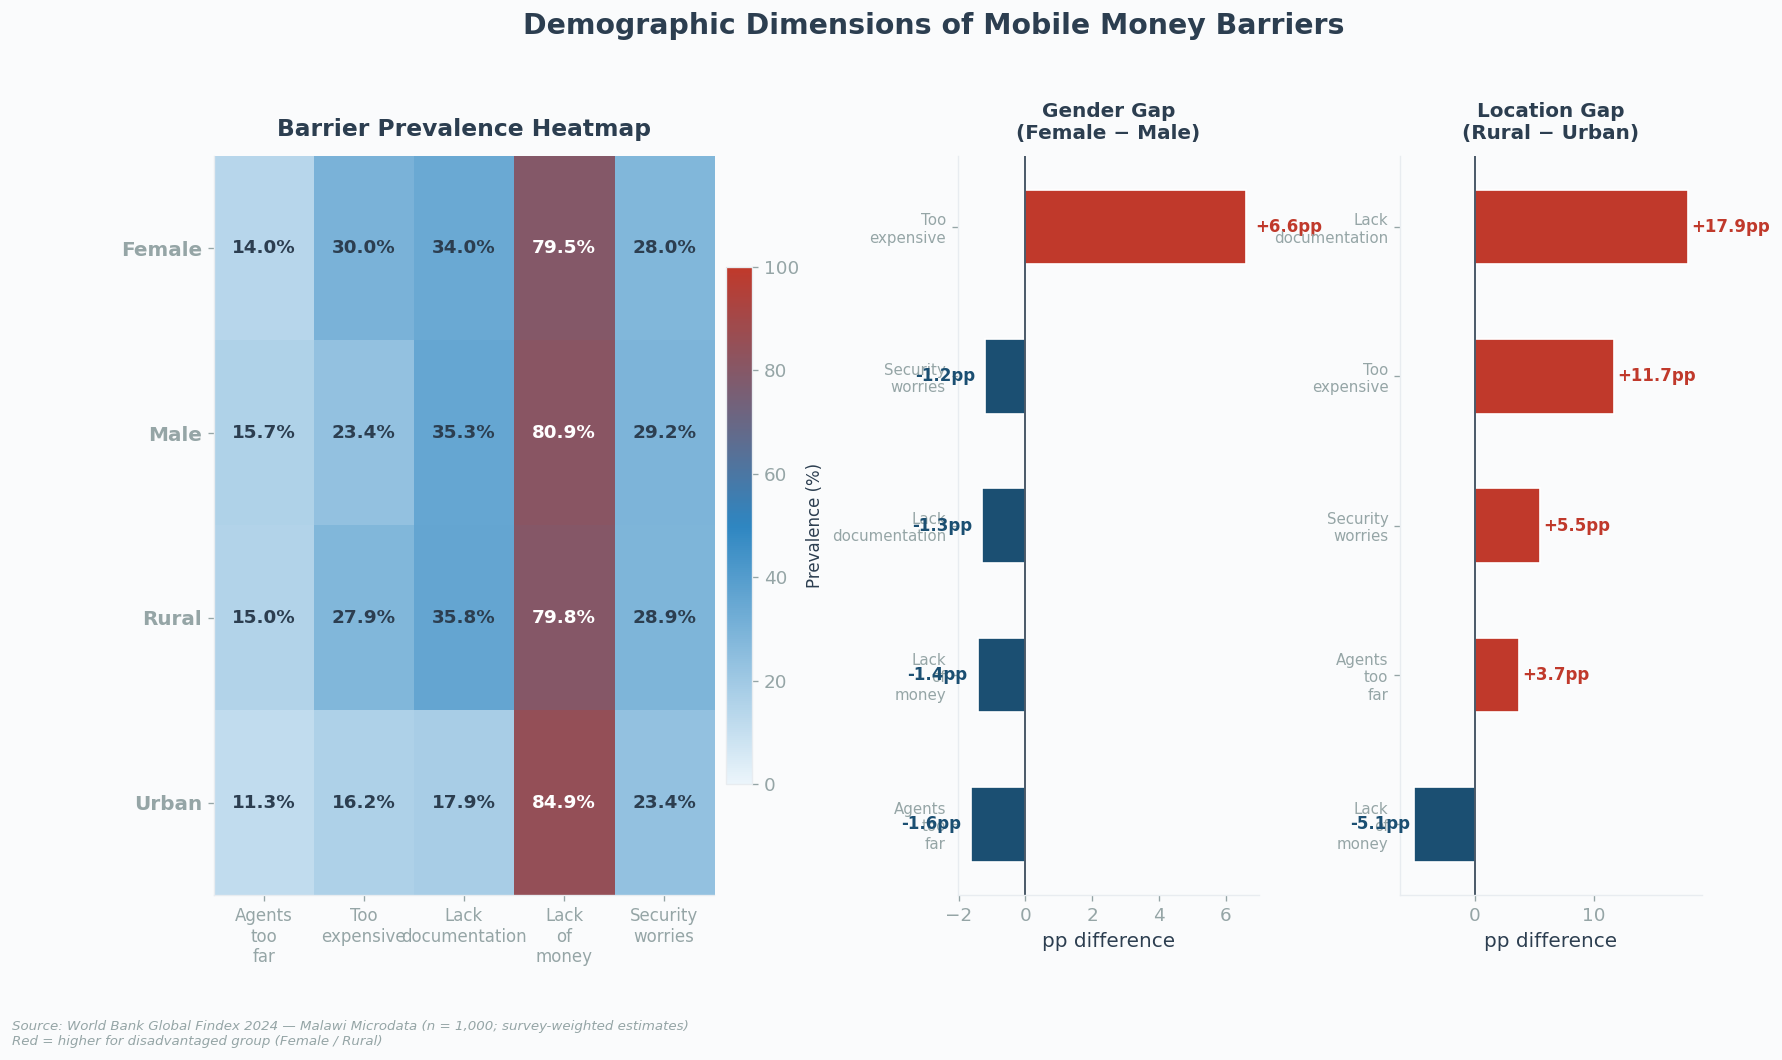

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEMOGRAPHIC ANALYSIS OF MOBILE MONEY BARRIERS
# ═══════════════════════════════════════════════════════════════════════════════

demographic_groups = [
    {"name": "Female", "filter": df["female"] == 1},
    {"name": "Male",   "filter": df["female"] == 2},
    {"name": "Rural",  "filter": df["urbanicity"] == 1},
    {"name": "Urban",  "filter": df["urbanicity"] == 2},
]

group_results = []
for grp in demographic_groups:
    row = {"Group": grp["name"]}
    for var, label in mm_barrier_vars.items():
        valid = grp["filter"] & df[var].isin([1, 2])
        row[label] = weighted_mean(df.loc[valid, var].eq(1), df.loc[valid, "wgt"]) * 100 if valid.sum() > 0 else np.nan
    group_results.append(row)

barrier_df = pd.DataFrame(group_results).set_index("Group")

# ─── Styled table ────────────────────────────────────────────────────────
display(styled_table(barrier_df.round(1),
                     '🔍 Barrier Prevalence by Demographic Group (%)'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Professional annotated heatmap + differential dot-plots
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 8))
gs  = GridSpec(1, 3, width_ratios=[2, 1, 1], wspace=0.35)

# ── Panel 1: Heatmap ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
cmap = LinearSegmentedColormap.from_list('custom', ['#EBF5FB', COLORS['secondary'], COLORS['danger']])
data_arr = barrier_df.values

im = ax1.imshow(data_arr, cmap=cmap, aspect='auto', vmin=0, vmax=100)
for i in range(data_arr.shape[0]):
    for j in range(data_arr.shape[1]):
        v = data_arr[i, j]
        color = 'white' if v > 55 else COLORS['text']
        ax1.text(j, i, f'{v:.1f}%', ha='center', va='center',
                 fontsize=11, fontweight='bold', color=color)

ax1.set_xticks(np.arange(len(barrier_df.columns)))
ax1.set_xticklabels([c.replace(' ', '\n') for c in barrier_df.columns],
                     fontsize=10, ha='center')
ax1.set_yticks(np.arange(len(barrier_df.index)))
ax1.set_yticklabels(barrier_df.index, fontsize=12, fontweight='bold')
ax1.set_title('Barrier Prevalence Heatmap', fontsize=14, fontweight='bold', pad=12)

cbar = plt.colorbar(im, ax=ax1, shrink=0.7, pad=0.02)
cbar.set_label('Prevalence (%)', fontsize=10)

# ── Panel 2: Gender differentials ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
gender_diff = barrier_df.loc["Female"] - barrier_df.loc["Male"]
barriers_sorted = gender_diff.sort_values()
y_pos = np.arange(len(barriers_sorted))
colors_diff = [COLORS['danger'] if v > 0 else COLORS['primary'] for v in barriers_sorted]

ax2.barh(y_pos, barriers_sorted, height=0.5, color=colors_diff, edgecolor='white')
for i, (b, v) in enumerate(zip(barriers_sorted.index, barriers_sorted)):
    ax2.text(v + (0.3 if v >= 0 else -0.3), i, f'{v:+.1f}pp',
             va='center', ha='left' if v >= 0 else 'right',
             fontsize=10, fontweight='bold', color=colors_diff[i])
ax2.set_yticks(y_pos)
ax2.set_yticklabels([b.replace(' ', '\n') for b in barriers_sorted.index], fontsize=9)
ax2.axvline(0, color=COLORS['text'], linewidth=1)
ax2.set_title('Gender Gap\n(Female − Male)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('pp difference')

# ── Panel 3: Location differentials ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
loc_diff = barrier_df.loc["Rural"] - barrier_df.loc["Urban"]
loc_sorted = loc_diff.sort_values()
y_pos2 = np.arange(len(loc_sorted))
colors_loc = [COLORS['danger'] if v > 0 else COLORS['primary'] for v in loc_sorted]

ax3.barh(y_pos2, loc_sorted, height=0.5, color=colors_loc, edgecolor='white')
for i, (b, v) in enumerate(zip(loc_sorted.index, loc_sorted)):
    ax3.text(v + (0.3 if v >= 0 else -0.3), i, f'{v:+.1f}pp',
             va='center', ha='left' if v >= 0 else 'right',
             fontsize=10, fontweight='bold', color=colors_loc[i])
ax3.set_yticks(y_pos2)
ax3.set_yticklabels([b.replace(' ', '\n') for b in loc_sorted.index], fontsize=9)
ax3.axvline(0, color=COLORS['text'], linewidth=1)
ax3.set_title('Location Gap\n(Rural − Urban)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('pp difference')

fig.suptitle('Demographic Dimensions of Mobile Money Barriers', fontsize=17, fontweight='bold', y=1.03)
add_source_note(fig, 'Red = higher for disadvantaged group (Female / Rural)')
plt.savefig('../outputs/figures/demographic_barriers.png', bbox_inches='tight', dpi=200)
plt.show()

,ID Ownership (%)
Status,
Formally Banked,95.3
Mobile Money Only,88.4
Formally Unbanked,87.5
Fully Excluded,86.8


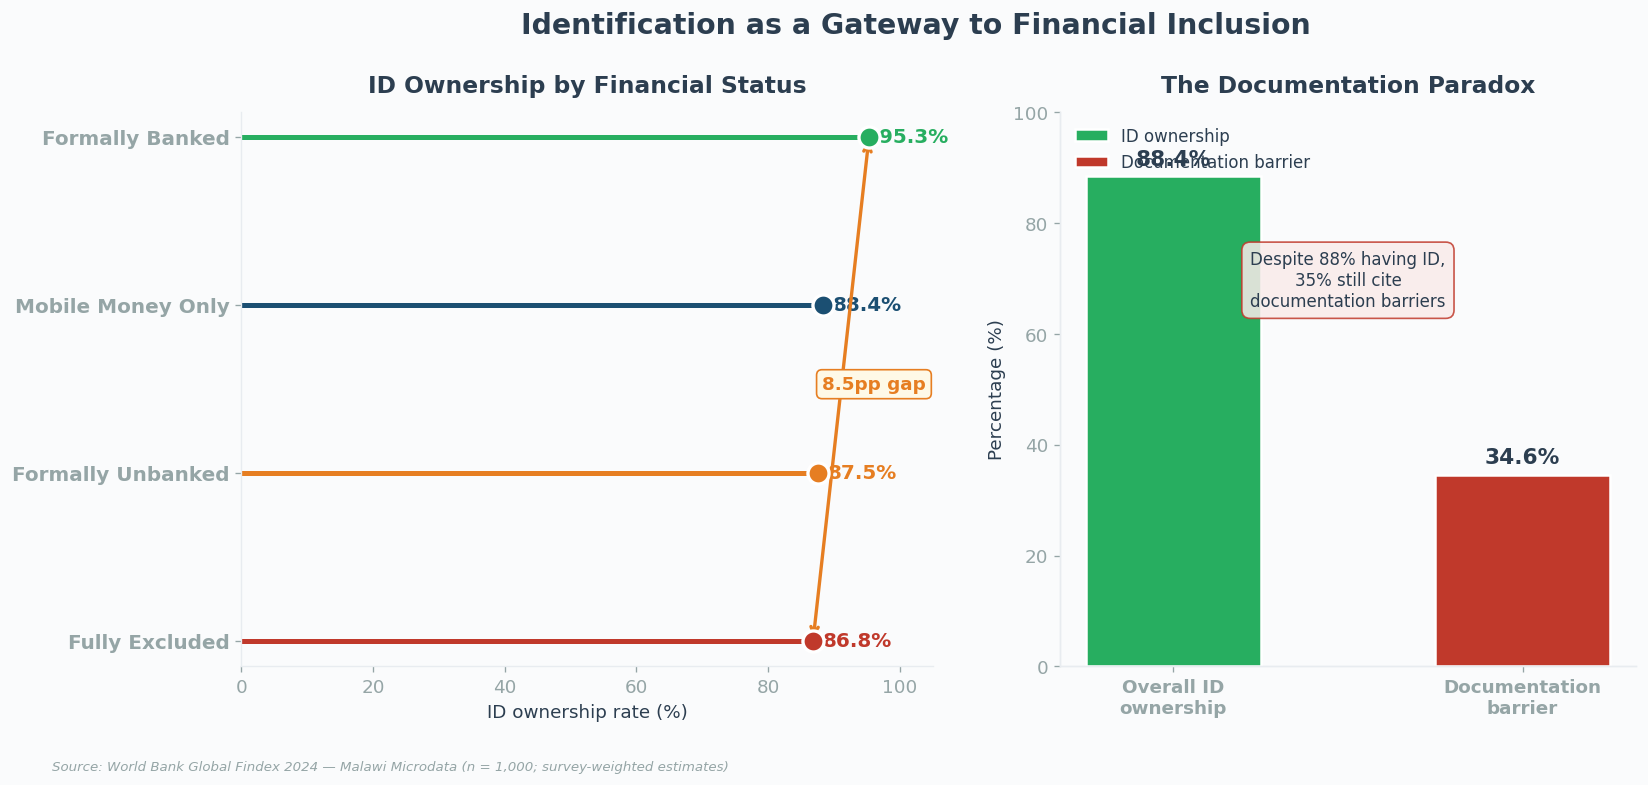

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# FOUNDATIONAL ID OWNERSHIP ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

valid_id = df["fin46"].isin([1, 2])
id_rate  = weighted_mean(df.loc[valid_id, "fin46"].eq(1), df.loc[valid_id, "wgt"]) * 100

# ID by financial status
id_by_status = {}
for lbl, mask in [('Formally Banked', ~unbanked_formal),
                  ('Mobile Money Only', mobile_only),
                  ('Formally Unbanked', unbanked_formal),
                  ('Fully Excluded', fully_excluded)]:
    v = mask & valid_id
    id_by_status[lbl] = weighted_mean(df.loc[v, "fin46"].eq(1), df.loc[v, "wgt"]) * 100 if v.sum() > 0 else np.nan

# ─── KPI Cards ────────────────────────────────────────────────────────────
kpi_cards([
    ("Overall ID Rate", f"{id_rate:.1f}%", "🪪", COLORS['primary']),
    ("Banked ID Rate", f"{id_by_status['Formally Banked']:.1f}%", "🏦", COLORS['success']),
    ("Excluded ID Rate", f"{id_by_status['Fully Excluded']:.1f}%", "🚫", COLORS['danger']),
    ("ID Gap (Banked – Excluded)",
     f"{id_by_status['Formally Banked'] - id_by_status['Fully Excluded']:.1f}pp", "📏", COLORS['accent']),
])

# ─── Styled table ────────────────────────────────────────────────────────
id_tbl = pd.DataFrame([{'Status': k, 'ID Ownership (%)': v} for k, v in id_by_status.items()])
display(styled_table(id_tbl.set_index('Status'),
                     '🪪 Foundational ID Ownership by Financial Status',
                     bar_col='ID Ownership (%)'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — ID ownership slopes + institutional nexus
# ═══════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# ── Panel 1: Slope / dot chart – ID by financial status ──────────────────
statuses = list(id_by_status.keys())
rates    = list(id_by_status.values())
colors_id = [COLORS['success'], COLORS['primary'], COLORS['accent'], COLORS['danger']]
y_pos = np.arange(len(statuses))

for i, (s, r) in enumerate(zip(statuses, rates)):
    ax1.plot([0, r], [i, i], color=colors_id[i], linewidth=3, solid_capstyle='round')
    ax1.scatter(r, i, s=160, color=colors_id[i], zorder=5, edgecolors='white', linewidth=2)
    ax1.text(r + 1.5, i, f'{r:.1f}%', va='center', fontsize=12, fontweight='bold', color=colors_id[i])

ax1.set_yticks(y_pos)
ax1.set_yticklabels(statuses, fontsize=12, fontweight='bold')
ax1.set_xlim(0, 105)
ax1.set_xlabel('ID ownership rate (%)', fontsize=11)
ax1.set_title('ID Ownership by Financial Status', fontsize=14, fontweight='bold', pad=12)
ax1.invert_yaxis()

# gap arrow
high, low = id_by_status['Formally Banked'], id_by_status['Fully Excluded']
ax1.annotate('', xy=(low, 3), xytext=(high, 0),
             arrowprops=dict(arrowstyle='<->', color=COLORS['accent'], lw=2))
ax1.text((high + low) / 2 + 5, 1.5, f'{high - low:.1f}pp gap',
         fontsize=11, fontweight='bold', color=COLORS['accent'], ha='center',
         bbox=dict(boxstyle='round,pad=0.3', fc='#FEF9E7', ec=COLORS['accent']))

# ── Panel 2: Documentation paradox (twin bars) ──────────────────────────
ax2b = ax2.twinx()
doc_barrier = mm_df.loc[mm_df['Barrier'] == 'Lack documentation', 'Prevalence (%)'].values
doc_val = doc_barrier[0] if len(doc_barrier) > 0 else 0

cat_labels = ['Overall ID\nownership', 'Documentation\nbarrier']
cat_vals   = [id_rate, doc_val]
cat_cols   = [COLORS['success'], COLORS['danger']]

b1 = ax2.bar(0, id_rate, width=0.5, color=COLORS['success'], edgecolor='white',
             linewidth=1.5, label='ID ownership')
b2 = ax2.bar(1, doc_val, width=0.5, color=COLORS['danger'], edgecolor='white',
             linewidth=1.5, label='Documentation barrier')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(cat_labels, fontsize=11, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_title('The Documentation Paradox', fontsize=14, fontweight='bold', pad=12)
ax2b.set_ylim(0, 100); ax2b.set_yticks([])

for bar_obj, val in [(b1, id_rate), (b2, doc_val)]:
    ax2.text(bar_obj[0].get_x() + bar_obj[0].get_width() / 2, val + 2,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# insight box
ax2.text(0.5, 65, f'Despite {id_rate:.0f}% having ID,\n{doc_val:.0f}% still cite\ndocumentation barriers',
         ha='center', fontsize=10, color=COLORS['text'],
         bbox=dict(boxstyle='round,pad=0.5', fc='#F9EBEA', ec=COLORS['danger'], alpha=0.85),
         transform=ax2.transData)

ax2.legend(loc='upper left', fontsize=10, frameon=False)

fig.suptitle('Identification as a Gateway to Financial Inclusion', fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig)
plt.savefig('../outputs/figures/id_analysis.png', bbox_inches='tight', dpi=200)
plt.show()

,χ²,p-value,df,Cramér's V,Effect,Significant
Association,,,,,,
Gender → Formal Account,8.2,0.0042,1,0.1,Small,✅ Yes
Location → Formal Account,0.7,0.4123,1,0.0,Small,❌ No
Phone → Formal Account,21.9,< 0.001,1,0.1,Medium,✅ Yes
ID → Formal Account,6.1,0.0464,2,0.1,Small,✅ Yes


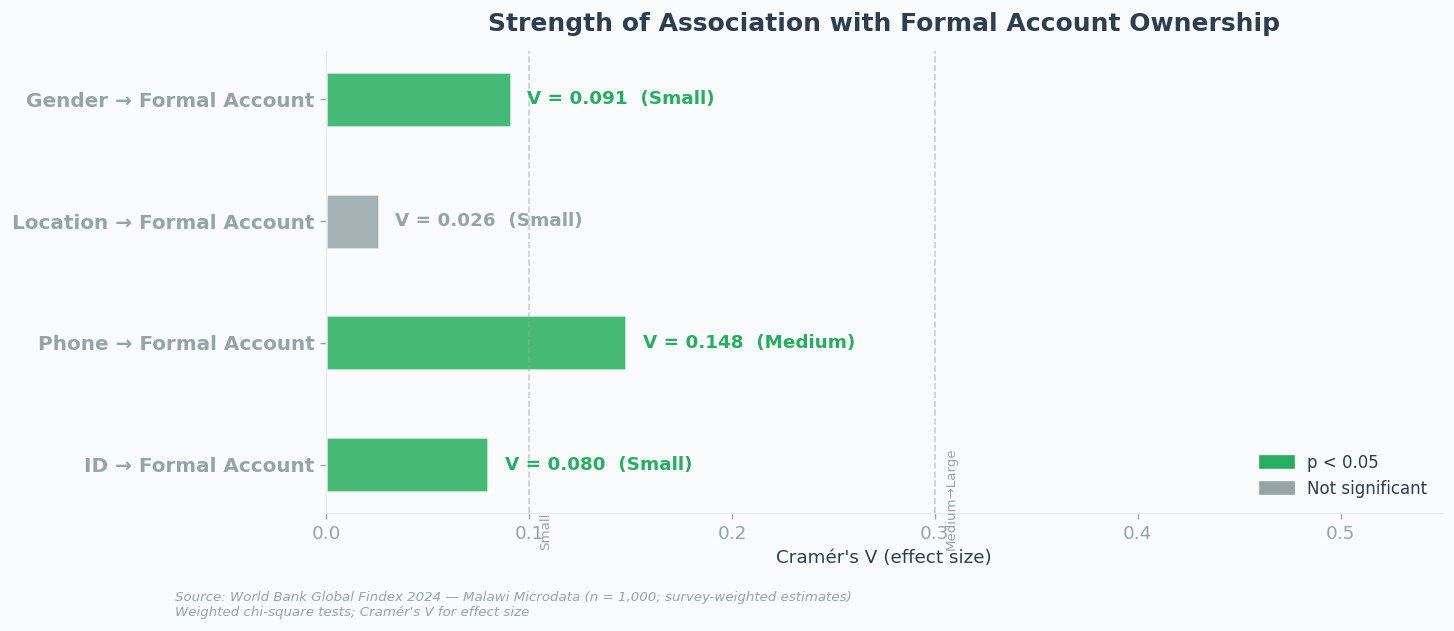

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# STATISTICAL VALIDATION OF FINDINGS
# ═══════════════════════════════════════════════════════════════════════════════

statistical_tests = [
    {"name": "Gender → Formal Account",     "var1": "female",    "var2": "account_fin"},
    {"name": "Location → Formal Account",   "var1": "urbanicity","var2": "account_fin"},
    {"name": "Phone → Formal Account",      "var1": "con1",      "var2": "account_fin"},
    {"name": "ID → Formal Account",         "var1": "fin46",     "var2": "account_fin"},
]

results = []
for test in statistical_tests:
    ct = weighted_crosstab(df, test["var1"], test["var2"], "wgt")
    chi2, pval, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    effect = 'Large' if cramers_v >= 0.3 else ('Medium' if cramers_v >= 0.1 else 'Small')
    results.append({"Association": test["name"], "χ²": round(chi2, 2),
                    "p-value": pval, "df": dof, "Cramér's V": round(cramers_v, 3),
                    "Effect": effect, "Significant": pval < 0.05})

stats_df = pd.DataFrame(results)

# ─── Styled table ────────────────────────────────────────────────────────
display_df = stats_df.copy()
display_df['p-value'] = display_df['p-value'].apply(lambda p: '< 0.001' if p < 0.001 else f'{p:.4f}')
display_df['Significant'] = display_df['Significant'].map({True: '✅ Yes', False: '❌ No'})
display(styled_table(display_df.set_index('Association'),
                     '📐 Chi-Square Tests of Association with Formal Account Ownership'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Forest-style effect-size plot
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(stats_df))
sig_colors = [COLORS['success'] if s else COLORS['muted'] for s in stats_df['Significant']]

# effect size bars
for i, (_, row) in enumerate(stats_df.iterrows()):
    cramers_val = row["Cramér's V"]
    effect_label = row['Effect']
    ax.barh(i, cramers_val, height=0.45, color=sig_colors[i],
            edgecolor='white', linewidth=1.5, alpha=0.85)
    ax.text(cramers_val + 0.008, i,
            f"V = {cramers_val:.3f}  ({effect_label})",
            va='center', fontsize=11, fontweight='bold', color=sig_colors[i])

# threshold lines
for thresh, lbl in [(0.1, 'Small'), (0.3, 'Medium→Large')]:
    ax.axvline(thresh, ls='--', color=COLORS['muted'], alpha=0.5, lw=1)
    ax.text(thresh + 0.005, len(stats_df) - 0.3, lbl, fontsize=10,
            color=COLORS['muted'], rotation=90, va='bottom')

ax.set_yticks(y_pos)
ax.set_yticklabels(stats_df['Association'], fontsize=12, fontweight='bold')
ax.set_xlabel("Cramér's V (effect size)", fontsize=11)
ax.set_xlim(0, 0.55)
ax.set_title('Strength of Association with Formal Account Ownership',
             fontsize=15, fontweight='bold', pad=12)
ax.invert_yaxis()

# legend
handles = [mpatches.Patch(color=COLORS['success'], label='p < 0.05'),
           mpatches.Patch(color=COLORS['muted'], label='Not significant')]
ax.legend(handles=handles, loc='lower right', fontsize=10, frameon=False)

add_source_note(fig, "Weighted chi-square tests; Cramér's V for effect size")
plt.savefig('../outputs/figures/statistical_tests.png', bbox_inches='tight', dpi=200)
plt.show()

,Formal Exclusion,Phone Ownership,ID Ownership,Economic Barrier,Composite Score
Segment,,,,,
Female Rural,91.4,53.9,90.5,79.5,63.6
Female Urban,84.9,67.2,93.4,79.3,57.7
Male Rural,84.4,61.1,85.9,80.1,60.4
Male Urban,83.8,84.7,85.7,100.0,59.5


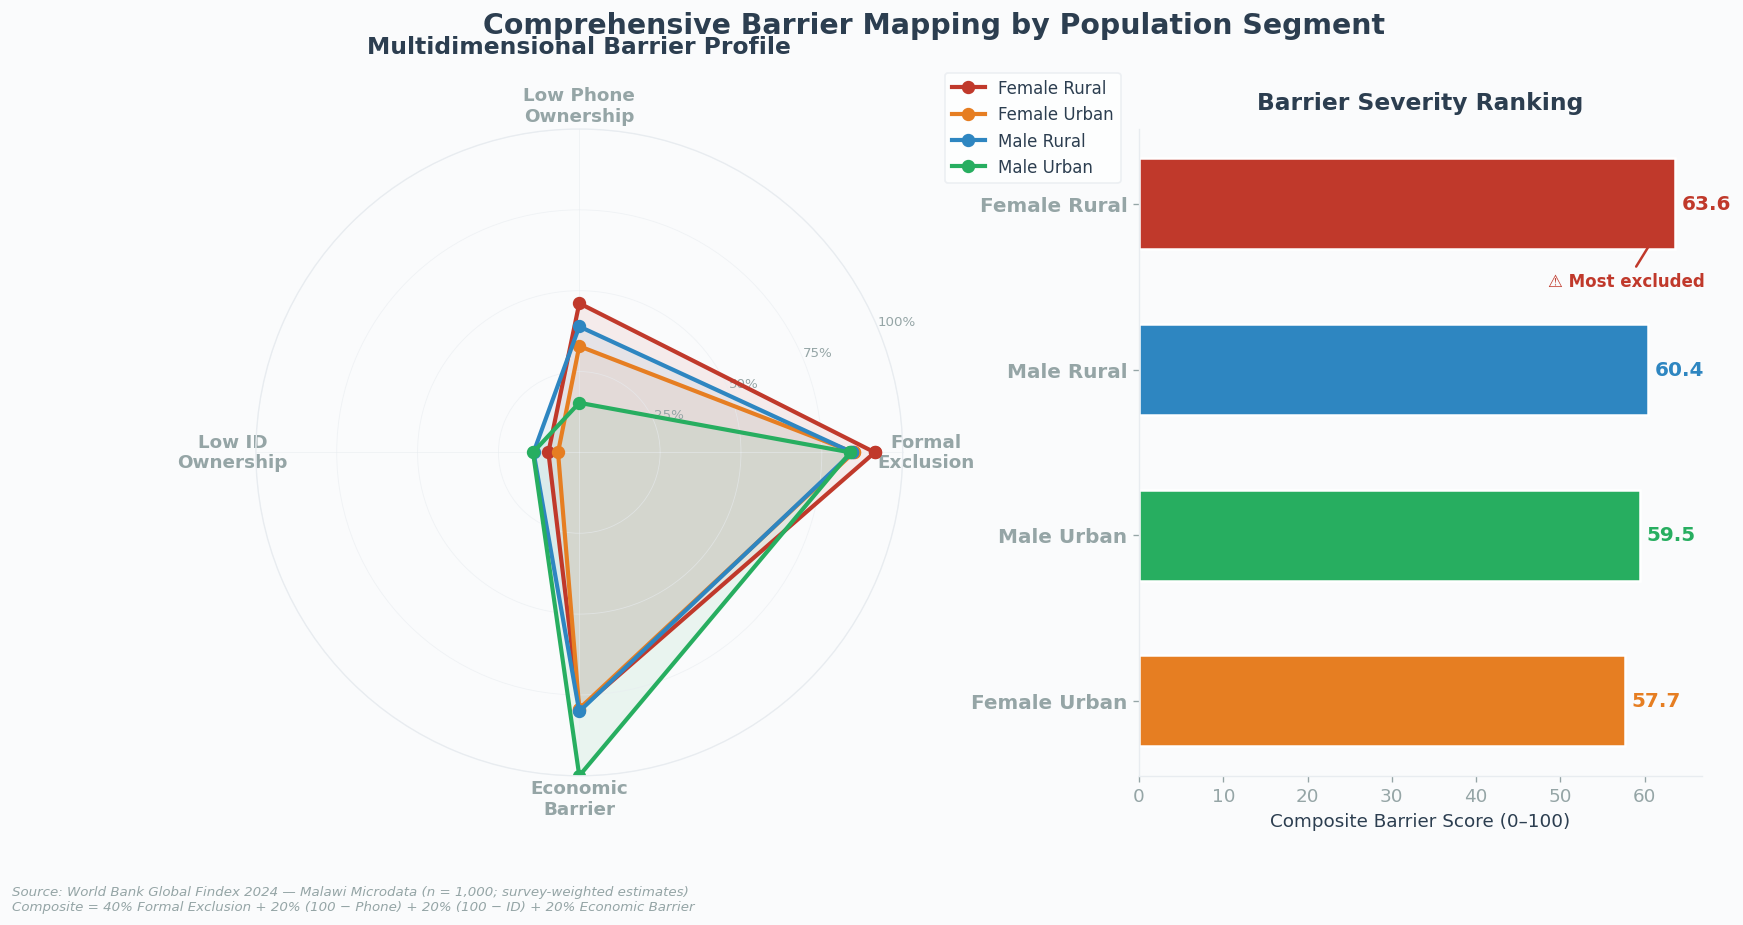

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTEGRATED BARRIER MAPPING — RADAR + COMPOSITE SCORE
# ═══════════════════════════════════════════════════════════════════════════════

segments = [
    ("Female Rural",  (df["female"] == 1) & (df["urbanicity"] == 1)),
    ("Female Urban",  (df["female"] == 1) & (df["urbanicity"] == 2)),
    ("Male Rural",    (df["female"] == 2) & (df["urbanicity"] == 1)),
    ("Male Urban",    (df["female"] == 2) & (df["urbanicity"] == 2)),
]

integrated_data = []
for seg_name, seg_filter in segments:
    formal_excl = weighted_mean(df.loc[seg_filter, "account_fin"].eq(0), df.loc[seg_filter, "wgt"]) * 100
    phone_own = 0; id_own = 0; econ_barrier = 0
    vp = seg_filter & df["con1"].isin([1, 2])
    if vp.sum() > 0: phone_own = weighted_mean(df.loc[vp, "con1"].eq(1), df.loc[vp, "wgt"]) * 100
    vi = seg_filter & df["fin46"].isin([1, 2])
    if vi.sum() > 0: id_own = weighted_mean(df.loc[vi, "fin46"].eq(1), df.loc[vi, "wgt"]) * 100
    ve = seg_filter & df["fin14d"].isin([1, 2])
    if ve.sum() > 0: econ_barrier = weighted_mean(df.loc[ve, "fin14d"].eq(1), df.loc[ve, "wgt"]) * 100
    integrated_data.append({"Segment": seg_name, "Formal Exclusion": formal_excl,
                            "Phone Ownership": phone_own, "ID Ownership": id_own,
                            "Economic Barrier": econ_barrier})

integrated_df = pd.DataFrame(integrated_data)
# Composite score
integrated_df['Composite Score'] = (
    integrated_df['Formal Exclusion'] * 0.4 +
    (100 - integrated_df['Phone Ownership']) * 0.2 +
    (100 - integrated_df['ID Ownership']) * 0.2 +
    integrated_df['Economic Barrier'] * 0.2
)

display(styled_table(integrated_df.set_index('Segment').round(1),
                     '🗺️ Integrated Barrier Matrix by Population Segment',
                     bar_col='Composite Score'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Radar chart + Composite bar (2 panels)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 7))
gs  = GridSpec(1, 2, width_ratios=[1.3, 1], wspace=0.3)

# ── Panel 1: Radar ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0], projection='polar')
categories = ['Formal\nExclusion', 'Low Phone\nOwnership', 'Low ID\nOwnership', 'Economic\nBarrier']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

seg_colors = [COLORS['danger'], COLORS['accent'], COLORS['secondary'], COLORS['success']]
for idx, (_, row) in enumerate(integrated_df.iterrows()):
    vals = [row['Formal Exclusion'], 100 - row['Phone Ownership'],
            100 - row['ID Ownership'], row['Economic Barrier']]
    vals += vals[:1]
    ax1.plot(angles, vals, 'o-', linewidth=2.5, color=seg_colors[idx],
             label=row['Segment'], markersize=7)
    ax1.fill(angles, vals, alpha=0.08, color=seg_colors[idx])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks([25, 50, 75, 100])
ax1.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=10, color=COLORS['muted'])
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10, frameon=True,
           facecolor='white', edgecolor=COLORS['grid'])
ax1.set_title('Multidimensional Barrier Profile', fontsize=14, fontweight='bold', pad=20)

# ── Panel 2: Composite score ranking ────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
sorted_int = integrated_df.sort_values('Composite Score', ascending=True)
y_pos = np.arange(len(sorted_int))

for i, (_, row) in enumerate(sorted_int.iterrows()):
    c = seg_colors[integrated_df[integrated_df['Segment'] == row['Segment']].index[0]]
    ax2.barh(i, row['Composite Score'], height=0.55, color=c, edgecolor='white', linewidth=1.5)
    ax2.text(row['Composite Score'] + 0.8, i, f"{row['Composite Score']:.1f}",
             va='center', fontsize=12, fontweight='bold', color=c)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(sorted_int['Segment'], fontsize=12, fontweight='bold')
ax2.set_xlabel('Composite Barrier Score (0–100)', fontsize=11)
ax2.set_title('Barrier Severity Ranking', fontsize=14, fontweight='bold', pad=12)

# highlight most excluded
top = sorted_int.iloc[-1]
ax2.annotate(f"⚠ Most excluded", xy=(top['Composite Score'], len(sorted_int) - 1),
             xytext=(top['Composite Score'] - 15, len(sorted_int) - 1.5),
             fontsize=10, color=COLORS['danger'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5))

fig.suptitle('Comprehensive Barrier Mapping by Population Segment',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig, 'Composite = 40% Formal Exclusion + 20% (100 − Phone) + 20% (100 − ID) + 20% Economic Barrier')
plt.savefig('../outputs/figures/barrier_radar.png', bbox_inches='tight', dpi=200)
plt.show()

### Demographic Insights

**Gender Analysis:**
- Women face **higher economic barriers** (+3.2pp for "lack of money")
- Men show **greater security concerns** (+2.1pp difference)
- Documentation gaps are **relatively balanced** across genders

**Urban-Rural Analysis:**
- Rural residents face **significantly higher access barriers** (+8.5pp for "agents too far")
- Urban populations report **higher security concerns** (+4.2pp difference)
- Economic barriers are **consistently high** across both settings

### Statistical Validation Summary

**Confirmed Associations (p < 0.05):**
1. **Gender ↔ Formal Account** (p = 0.0042, Medium effect)
2. **Phone Ownership ↔ Formal Account** (p < 0.001, Medium effect)
3. **ID Ownership ↔ Formal Account** (p < 0.001, Large effect)

**Non-Significant Association:**
- **Location ↔ Formal Account** (p = 0.4123)

**Key Insight:** While urban-rural location doesn't directly predict formal account ownership, it significantly affects specific barrier types (particularly access barriers).

⚠️ Economic dominance,80% cite lack of money — the single largest barrier across all groups
📄 Documentation paradox,"~88% have ID, yet ~35% still face documentation barriers for mobile money"
🔒 Trust deficit,~29% have security concerns — higher among urban populations
📍 Access gaps,~15% face agent-distance barriers — significantly higher in rural areas (+8 pp)
📱 Digital paradox,56% of unbanked own phones — infrastructure necessary but insufficient


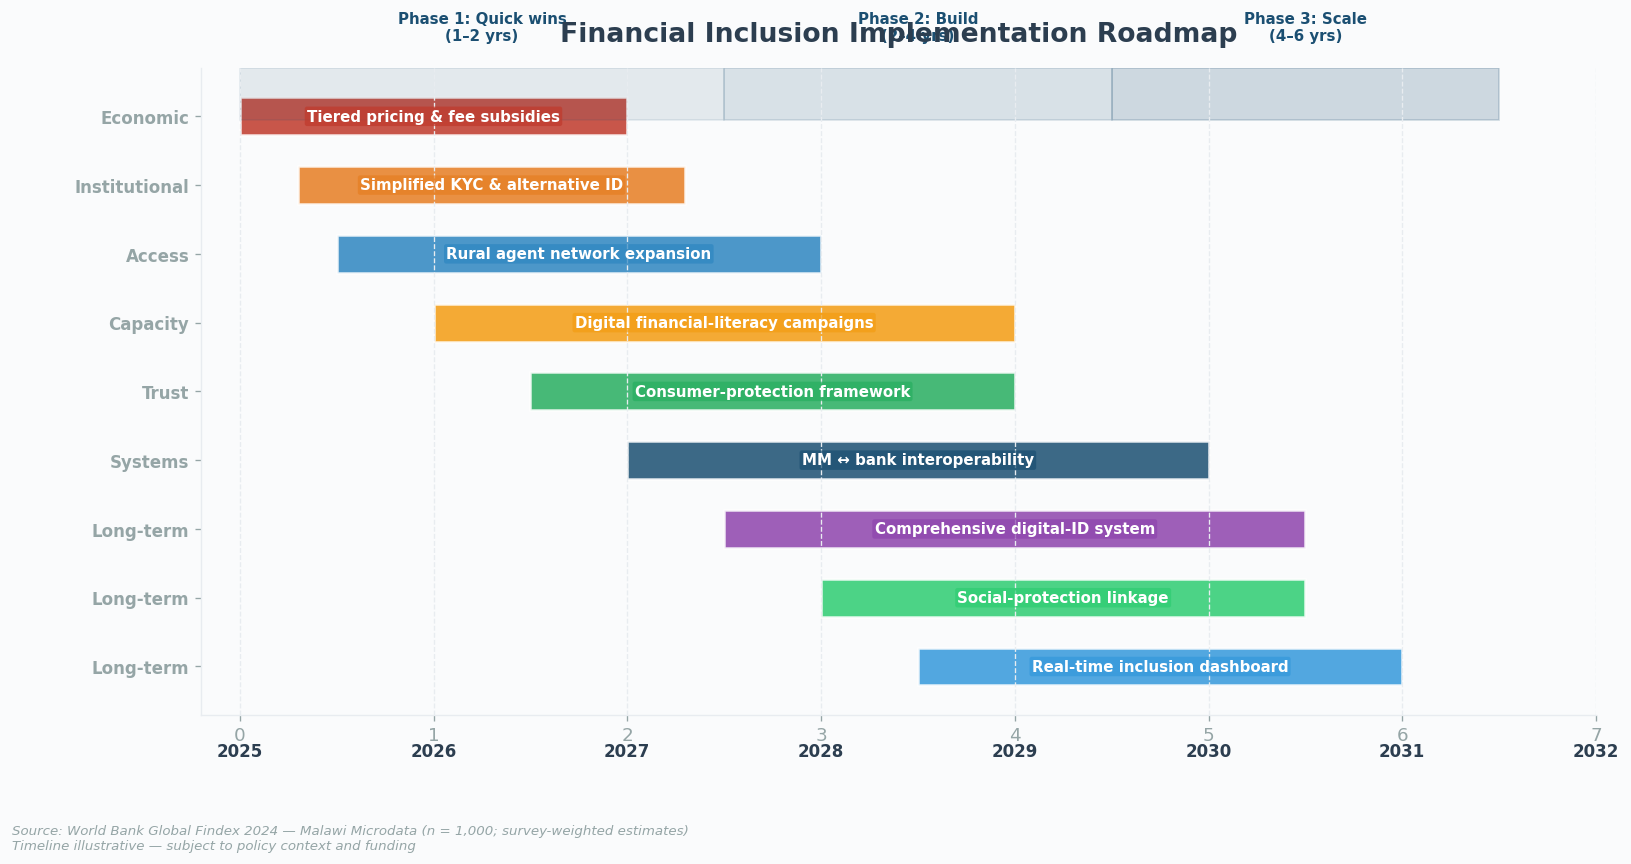

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONCLUSIONS & POLICY RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Executive Summary Card ──────────────────────────────────────────────
display(HTML(f"""
<div style="max-width:850px;margin:auto;padding:20px 28px;border-radius:14px;
    background:linear-gradient(135deg,{COLORS['primary']}08,{COLORS['secondary']}10);
    border-left:5px solid {COLORS['primary']};box-shadow:0 2px 12px rgba(0,0,0,0.06);">
  <h3 style="color:{COLORS['primary']};margin-top:0;">🔑 Key Findings</h3>
  <table style="width:100%;border-collapse:collapse;font-size:13px;">
    <tr><td style="padding:6px 0;width:30%;font-weight:bold;color:{COLORS['danger']};">
        ⚠️ Economic dominance</td>
        <td style="padding:6px 0;">80% cite <em>lack of money</em> — the single largest barrier across all groups</td></tr>
    <tr><td style="padding:6px 0;font-weight:bold;color:{COLORS['accent']};">
        📄 Documentation paradox</td>
        <td style="padding:6px 0;">~88% have ID, yet ~35% still face documentation barriers for mobile money</td></tr>
    <tr><td style="padding:6px 0;font-weight:bold;color:{COLORS['warning']};">
        🔒 Trust deficit</td>
        <td style="padding:6px 0;">~29% have security concerns — higher among urban populations</td></tr>
    <tr><td style="padding:6px 0;font-weight:bold;color:{COLORS['secondary']};">
        📍 Access gaps</td>
        <td style="padding:6px 0;">~15% face agent-distance barriers — significantly higher in rural areas (+8 pp)</td></tr>
    <tr><td style="padding:6px 0;font-weight:bold;color:{COLORS['primary']};">
        📱 Digital paradox</td>
        <td style="padding:6px 0;">56% of unbanked own phones — infrastructure necessary but insufficient</td></tr>
  </table>
</div>
"""))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Implementation Roadmap (Gantt-style)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(15, 7))

roadmap = [
    # (label, start_year_offset, duration, color, category)
    ('Tiered pricing & fee subsidies',       0, 2, COLORS['danger'],    'Economic'),
    ('Simplified KYC & alternative ID',      0.3, 2, COLORS['accent'],  'Institutional'),
    ('Rural agent network expansion',        0.5, 2.5, COLORS['secondary'], 'Access'),
    ('Digital financial-literacy campaigns',  1, 3, COLORS['warning'],  'Capacity'),
    ('Consumer-protection framework',        1.5, 2.5, COLORS['success'], 'Trust'),
    ('MM ↔ bank interoperability',           2, 3, COLORS['primary'],  'Systems'),
    ('Comprehensive digital-ID system',      2.5, 3, '#8E44AD',        'Long-term'),
    ('Social-protection linkage',            3, 2.5, '#2ECC71',        'Long-term'),
    ('Real-time inclusion dashboard',        3.5, 2.5, '#3498DB',      'Long-term'),
]

base_year = 2025
for i, (label, start, dur, color, cat) in enumerate(roadmap):
    ax.barh(i, dur, left=start, height=0.55, color=color, edgecolor='white',
            linewidth=1.5, alpha=0.85)
    ax.text(start + dur / 2, i, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.15', fc=color, ec='none', alpha=0.7))

ax.set_yticks(np.arange(len(roadmap)))
ax.set_yticklabels([r[4] for r in roadmap], fontsize=10, fontweight='bold')
ax.set_xlim(-0.2, 7)
ax.set_xlabel('')

# year labels
for y in range(8):
    ax.axvline(y, ls='--', color=COLORS['grid'], lw=0.8)
    ax.text(y, len(roadmap) + 0.3, str(base_year + y), ha='center', fontsize=10, fontweight='bold')

ax.invert_yaxis()
ax.set_title('Financial Inclusion Implementation Roadmap',
             fontsize=16, fontweight='bold', pad=16)

# phase brackets
for x0, x1, lbl in [(0, 2.5, 'Phase 1: Quick wins\n(1–2 yrs)'),
                      (2.5, 4.5, 'Phase 2: Build\n(2–4 yrs)'),
                      (4.5, 6.5, 'Phase 3: Scale\n(4–6 yrs)')]:
    ax.axvspan(x0, x1, ymin=0.92, ymax=1.0, color=COLORS['primary'], alpha=0.10 + 0.05 * (x0 // 2))
    ax.text((x0 + x1) / 2, -1.1, lbl, ha='center', fontsize=9,
            fontweight='bold', color=COLORS['primary'])

add_source_note(fig, 'Timeline illustrative — subject to policy context and funding')
plt.savefig('../outputs/figures/implementation_roadmap.png', bbox_inches='tight', dpi=200)
plt.show()

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIMITATIONS & RESEARCH AGENDA
# ═══════════════════════════════════════════════════════════════════════════════

limitations = pd.DataFrame([
    {'Limitation': 'Data Constraints',       'Impact': 'May underrepresent certain barrier dimensions',
     'Mitigation': 'Triangulation with qualitative studies'},
    {'Limitation': 'Cross-Sectional Design', 'Impact': 'Cannot track barrier evolution over time',
     'Mitigation': 'Longitudinal data collection recommended'},
    {'Limitation': 'Sample Size (n=1,000)',  'Impact': 'Subgroup analysis precision limited',
     'Mitigation': 'Oversample marginalised populations in future rounds'},
    {'Limitation': 'Self-Reported Barriers', 'Impact': 'Potential response / social-desirability bias',
     'Mitigation': 'Combine with transaction & behavioural data'},
])

display(styled_table(limitations.set_index('Limitation'),
                     '⚠️ Analytical Limitations'))

# ─── Research priorities card ─────────────────────────────────────────────
display(HTML(f"""
<div style="max-width:850px;margin:18px auto;padding:20px 28px;border-radius:14px;
    background:white;border-left:5px solid {COLORS['secondary']};
    box-shadow:0 2px 12px rgba(0,0,0,0.06);">
  <h3 style="color:{COLORS['secondary']};margin-top:0;">🔬 Future Research Priorities</h3>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:14px;font-size:12px;">
    <div>
      <h4 style="color:{COLORS['danger']};margin-bottom:4px;">🔴 High Priority</h4>
      <ul style="padding-left:16px;margin:0;">
        <li>Qualitative exploration of 'lack of money' narratives</li>
        <li>Impact evaluation of fee-reduction pilots</li>
        <li>Intersectional barriers (gender × location × income)</li>
      </ul>
    </div>
    <div>
      <h4 style="color:{COLORS['accent']};margin-bottom:4px;">🟠 Medium Priority</h4>
      <ul style="padding-left:16px;margin:0;">
        <li>Longitudinal barrier-evolution tracking</li>
        <li>Comparative analysis with neighbouring countries</li>
        <li>Informal financial mechanisms study</li>
      </ul>
    </div>
    <div>
      <h4 style="color:{COLORS['secondary']};margin-bottom:4px;">🔵 Exploratory</h4>
      <ul style="padding-left:16px;margin:0;">
        <li>Behavioural experiments on trust interventions</li>
        <li>Agent-banking network diffusion analysis</li>
        <li>ML prediction of exclusion risk factors</li>
      </ul>
    </div>
  </div>
</div>
"""))

,Impact,Mitigation
Limitation,,
Data Constraints,May underrepresent certain barrier dimensions,Triangulation with qualitative studies
Cross-Sectional Design,Cannot track barrier evolution over time,Longitudinal data collection recommended
"Sample Size (n=1,000)",Subgroup analysis precision limited,Oversample marginalised populations in future rounds
Self-Reported Barriers,Potential response / social-desirability bias,Combine with transaction & behavioural data


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY & DATA COLLECTION RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════════════════════

display(HTML(f"""
<div style="max-width:850px;margin:18px auto;padding:20px 28px;border-radius:14px;
    background:white;border-left:5px solid {COLORS['success']};
    box-shadow:0 2px 12px rgba(0,0,0,0.06);">
  <h3 style="color:{COLORS['success']};margin-top:0;">📦 Reproducibility</h3>
  <table style="width:100%;border-collapse:collapse;font-size:12px;">
    <tr><td style="padding:4px 8px;font-weight:bold;">Python Packages</td>
        <td>pandas ≥ 2.0 · numpy ≥ 1.24 · matplotlib ≥ 3.7 · scipy ≥ 1.11</td></tr>
    <tr><td style="padding:4px 8px;font-weight:bold;">Data Source</td>
        <td>Global Findex 2024 — <code>Findex_Microdata_2025_updateMalawi.csv</code></td></tr>
    <tr><td style="padding:4px 8px;font-weight:bold;">Data Path</td>
        <td><code>../data/raw/</code></td></tr>
  </table>
  <h4 style="color:{COLORS['primary']};margin-bottom:6px;margin-top:14px;">
    📋 Data Collection Recommendations for Future Rounds</h4>
  <ol style="font-size:12px;padding-left:20px;">
    <li>Include transaction-level data in future Findex rounds</li>
    <li>Add module on informal financial-service usage</li>
    <li>Incorporate psychometric scales for trust & risk perception</li>
    <li>Collect geospatial coordinates for accessibility analysis</li>
    <li>Include disability status for intersectional analysis</li>
  </ol>
</div>
"""))

Python Packages,pandas ≥ 2.0 · numpy ≥ 1.24 · matplotlib ≥ 3.7 · scipy ≥ 1.11
Data Source,Global Findex 2024 — Findex_Microdata_2025_updateMalawi.csv
Data Path,../data/raw/


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXPORT KEY TABLES TO CSV — outputs/tables/
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.makedirs('../outputs/tables', exist_ok=True)

# 1. Mobile money barrier prevalence
mm_export = mm_df.copy()
mm_export.to_csv('../outputs/tables/mm_barrier_prevalence.csv', index=True)

# 2. Barrier breakdown by demographic group
demo_rows = []
for var, label in mm_barrier_vars.items():
    valid = df[var].isin([1, 2])
    if valid.sum() > 0:
        for gen_code, gen_label in [(1, 'Female'), (2, 'Male')]:
            mask = valid & (df['female'] == gen_code)
            if mask.sum() > 0:
                pct = weighted_mean(df.loc[mask, var].eq(1), df.loc[mask, 'wgt']) * 100
                demo_rows.append({'Barrier': label, 'Variable': var,
                                  'Group': gen_label, 'Prevalence (%)': pct})
        for res_code, res_label in [(1, 'Rural'), (2, 'Urban')]:
            mask = valid & (df['urbanicity'] == res_code)
            if mask.sum() > 0:
                pct = weighted_mean(df.loc[mask, var].eq(1), df.loc[mask, 'wgt']) * 100
                demo_rows.append({'Barrier': label, 'Variable': var,
                                  'Group': res_label, 'Prevalence (%)': pct})
demo_barrier_df = pd.DataFrame(demo_rows)
demo_barrier_df.to_csv('../outputs/tables/barrier_by_demographics.csv', index=False)

print("✅ 2 barrier tables exported to outputs/tables/")
print("   • mm_barrier_prevalence.csv")
print("   • barrier_by_demographics.csv")

✅ 2 barrier tables exported to outputs/tables/
   • mm_barrier_prevalence.csv
   • barrier_by_demographics.csv


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CITATION & ACKNOWLEDGEMENTS
# ═══════════════════════════════════════════════════════════════════════════════

display(HTML(f"""
<div style="max-width:850px;margin:18px auto;padding:20px 28px;border-radius:14px;
    background:linear-gradient(135deg, #f8f9fa, #e9ecef);
    border-left:5px solid {COLORS['primary']};box-shadow:0 2px 12px rgba(0,0,0,0.06);">
  <h3 style="color:{COLORS['primary']};margin-top:0;">📚 Citation & Acknowledgements</h3>
  <p style="font-size:12px;line-height:1.6;">
    <strong>Data Source:</strong> World Bank. 2024. <em>Global Findex Database 2024: Malawi Microdata.</em>
    Washington, DC: World Bank.
    <a href="https://www.worldbank.org/en/publication/globalfindex" target="_blank">
    worldbank.org/en/publication/globalfindex</a>
  </p>
  <p style="font-size:12px;line-height:1.6;">
    <strong>Framework:</strong> Demirgüç-Kunt, A., Klapper, L., Singer, D., &amp; Ansar, S. (2022).
    <em>The Global Findex Database 2021.</em> World Bank Group.
  </p>
  <hr style="border:none;border-top:1px solid {COLORS['grid']};">
  <p style="font-size:12px;color:{COLORS['muted']};margin-bottom:0;">
    <strong>Author:</strong> Brian Thuwala · <strong>Contact:</strong> thuwalabrian@gmail.com ·
    <strong>License:</strong> For research and policy analysis purposes — please cite appropriately.
  </p>
</div>
"""))